# 02 — Train and evaluate both models

`price` predicts `price_valuation_inr` (carbon is an input feature).
`carbon` predicts `estimated_carbon_emission_grams` from everything except itself.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

from src.models.data_loader import load_data
from src.models.predict import model_path, predict_single
from src.models.schema import TASKS
from src.models.train import DEFAULT_DATA, train

## Train both tasks (writes the same .pkl files as `make train`)

In [2]:
results = {}
for task in TASKS:
    model, metrics = train(DEFAULT_DATA, task=task)
    results[task] = (model, metrics)
    print(task, "->", model_path(task))
pd.DataFrame({t: m for t, (_, m) in results.items()}).T

price -> models/rf_pipeline.pkl


carbon -> models/rf_carbon_pipeline.pkl


,MAE,MSE,RMSE,R2
price,175.544424,3.084935e+05,555.421907,0.997735
carbon,2625.848179,1.931995e+07,4395.446269,0.991477


## Predicted vs actual on a held-out split

Same seed/split as `train()`, so these rows were not fitted on.

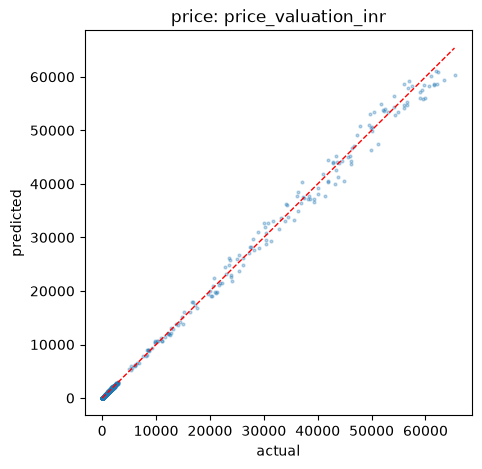

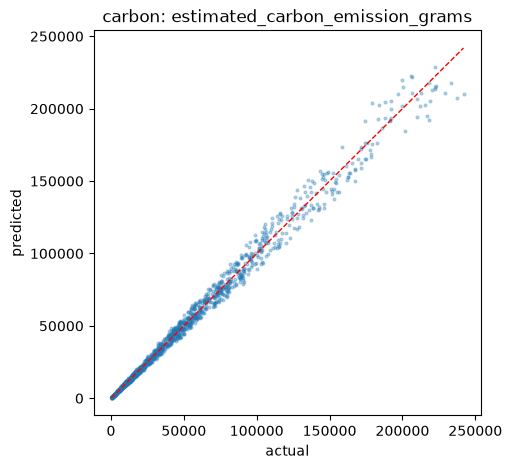

In [3]:
df = load_data(DEFAULT_DATA)

for task, (model, _) in results.items():
    spec = TASKS[task]
    _, X_test, _, y_test = train_test_split(
        df[spec["features"]], df[spec["target"]], test_size=0.2, random_state=42
    )
    preds = model.predict(X_test)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(y_test, preds, s=4, alpha=0.3)
    lo, hi = y_test.min(), y_test.max()
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)
    ax.set(xlabel="actual", ylabel="predicted", title=f"{task}: {spec['target']}")
    plt.show()

## Feature importance

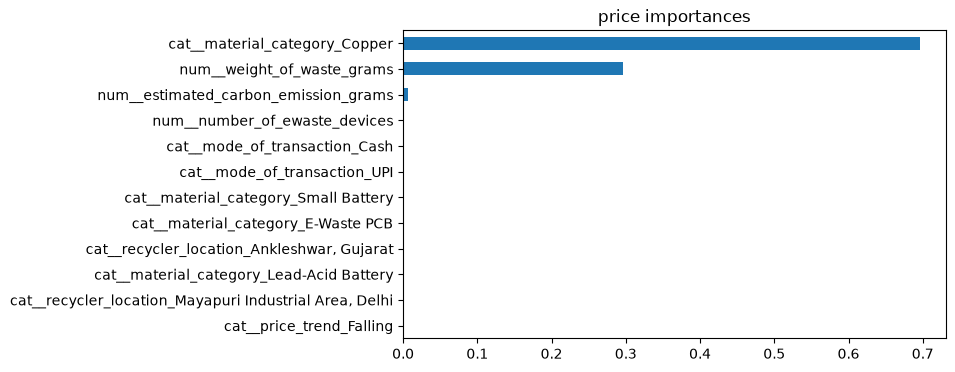

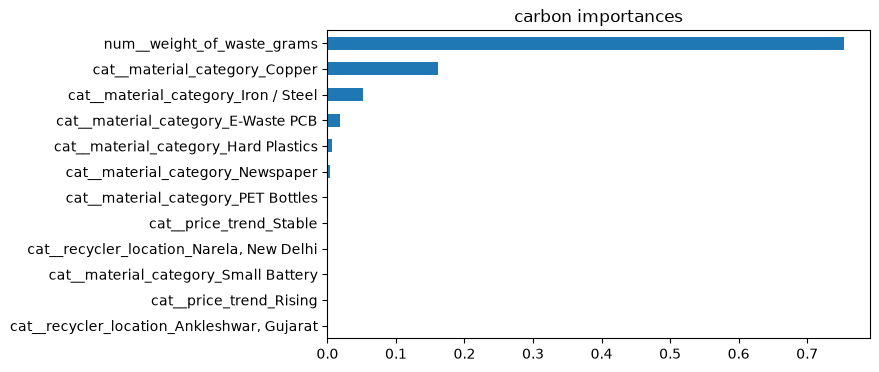

In [4]:
for task, (model, _) in results.items():
    names = model.named_steps["preprocessor"].get_feature_names_out()
    imp = pd.Series(model.named_steps["regressor"].feature_importances_, index=names)
    imp.nlargest(12).sort_values().plot.barh(figsize=(7, 4), title=f"{task} importances")
    plt.show()

## Single-row inference — same call path as the API

In [5]:
row = {
    "weight_of_waste_grams": 61316.9,
    "number_of_ewaste_devices": 0,
    "estimated_carbon_emission_grams": 61076.1,
    "material_category": "PET Bottles",
    "price_trend": "Stable",
    "mode_of_transaction": "Cash",
    "recycler_location": "Guindy, Chennai",
    "authorization_status": "Authorized",
}
carbon = predict_single(row, results["carbon"][0], "carbon")
price = predict_single(row, results["price"][0], "price")
print(f"carbon: {carbon:.2f} g   price: INR {price:.2f}")

carbon: 67547.02 g   price: INR 939.21


Serve these models with `make serve`, then `POST /predict/price` and `POST /predict/carbon`.